In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

D:\Anaconda\envs\AI\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
img_height = 224
img_width = 224
batch_size = 32

In [3]:
train_data = ImageDataGenerator(
    rescale=1./255,
)

val_data = ImageDataGenerator(
    rescale=1./255
)

In [4]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "Fruit/train",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "Fruit/val",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

Found 5600 files belonging to 8 classes.
Found 1600 files belonging to 8 classes.


In [11]:
# AUTOTUNE = tf.data.AUTOTUNE

# train_data = train_data.map(
#     lambda x, y: (x / 255.0, y),
#     num_parallel_calls=AUTOTUNE
# ).cache().prefetch(AUTOTUNE)

# val_data = val_data.map(
#     lambda x, y: (x / 255.0, y),
#     num_parallel_calls=AUTOTUNE
# ).cache().prefetch(AUTOTUNE)

In [12]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [13]:
# model = Sequential()

# # Convolution Block 1
# model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
# model.add(MaxPooling2D(2,2))

# # Convolution Block 2
# model.add(Conv2D(64, (3,3), activation='relu'))
# model.add(MaxPooling2D(2,2))

# # Convolution Block 3
# model.add(Conv2D(128, (3,3), activation='relu'))
# model.add(MaxPooling2D(2,2))

# # Fully Connected Layers
# model.add(Flatten())
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(train_data.num_classes, activation='softmax'))

In [14]:
model = Sequential([
    data_augmentation,
    Conv2D(32, (3,3), padding="same", activation="relu",input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),
    
    Conv2D(128, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(train_data.element_spec[1].shape[-1], activation="softmax")
])

D:\Anaconda\envs\AI\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6
    )
]

In [17]:
history = model.fit(
    train_data,
    validation_data=val_data,
    # steps_per_epoch=100,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.4571 - loss: 1.7163 - val_accuracy: 0.6056 - val_loss: 1.1662 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.6027 - loss: 1.2229 - val_accuracy: 0.6619 - val_loss: 1.0910 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.6455 - loss: 1.0514 - val_accuracy: 0.6938 - val_loss: 0.8905 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.6823 - loss: 0.9378 - val_accuracy: 0.6888 - val_loss: 0.9214 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.7061 - loss: 0.8444 - val_accuracy: 0.7113 - val_loss: 0.8059 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.7479 - loss: 0.7382 - val_accuracy: 0.7525 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 225s 1s/step - accuracy: 0.7664 - loss: 0.

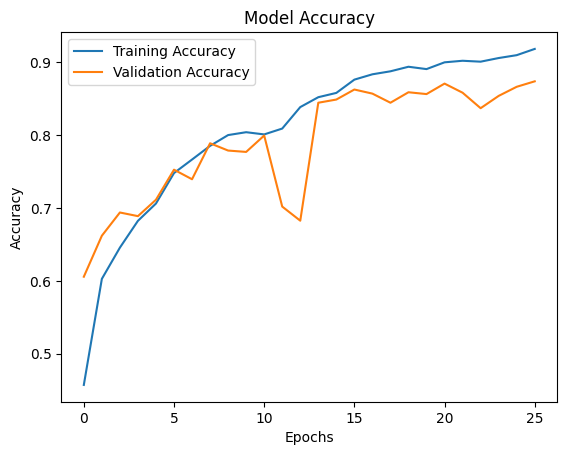

In [18]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

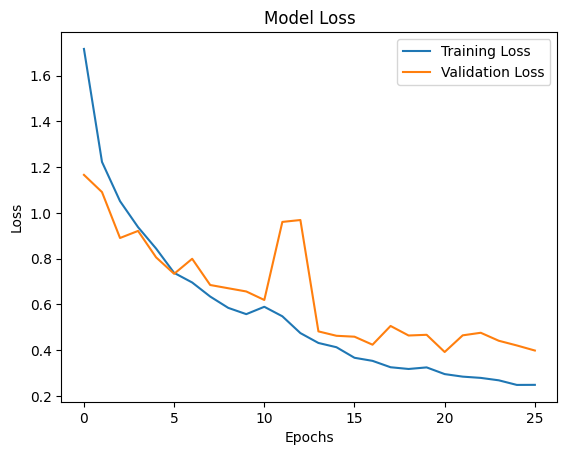

In [19]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

In [20]:
model.save("CNN_MODEL_FRUIT_CLASSIFICATION_2.h5")

In [21]:
import json
with open("Trained_History_PROJECT_FRUIT_2.json",'w') as f:
    json.dump(history.history,f)

In [5]:
test_data = ImageDataGenerator(rescale=1./255)

In [10]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    'fruit/test/',
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=8
)

# test_data = test_data.map(lambda x, y: (x/255.0, y))

val_loss, val_acc = model.evaluate(test_data)
val_acc = val_acc *100
print(f"Test Accuracy: {val_acc:.2f}")

Found 800 files belonging to 8 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.8813 - loss: 0.3661
Test Accuracy: 88.13


In [9]:
class_names=train_data.class_names

In [7]:
model = tf.keras.models.load_model("CNN_MODEL_FRUIT_CLASSIFICATION_2.h5")

In [ ]:
# Evaluate directly on dataset (BEST)
test_loss, test_accuracy = model.evaluate(test_data, verbose=0)

print('=' * 55)
print('  FINAL TEST SET RESULTS')
print('=' * 55)
print(f'  Test Accuracy : {test_accuracy * 100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 55)

# Collect all true labels
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in test_data])

# Predict probabilities for all images
y_prob = model.predict(test_data, verbose=0)

# Predicted labels
y_pred = np.argmax(y_prob, axis=1)

idx = 1
print(f'\nExample Prediction (Test image {idx}):')
print(f'  True label  : {y_true[idx]} ({class_names[y_true[idx]]})')
print(f'  Predicted   : {y_pred[idx]} ({class_names[y_pred[idx]]})')
print(f'  Confidence  : {y_prob[idx][y_pred[idx]] * 100:.1f}%')

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print('\nDetailed Classification Report')
print('=' * 70)
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=3
))


Detailed Classification Report
              precision    recall  f1-score   support

       Apple      0.163     0.130     0.144       100
     Avocado      0.144     0.150     0.147       100
      Banana      0.124     0.130     0.127       100
      Grapes      0.117     0.120     0.118       100
  Mangosteen      0.104     0.110     0.107       100
      Orange      0.144     0.150     0.147       100
   Pineapple      0.133     0.120     0.126       100
 Pomegranate      0.074     0.080     0.077       100

    accuracy                          0.124       800
   macro avg      0.125     0.124     0.124       800
weighted avg      0.125     0.124     0.124       800



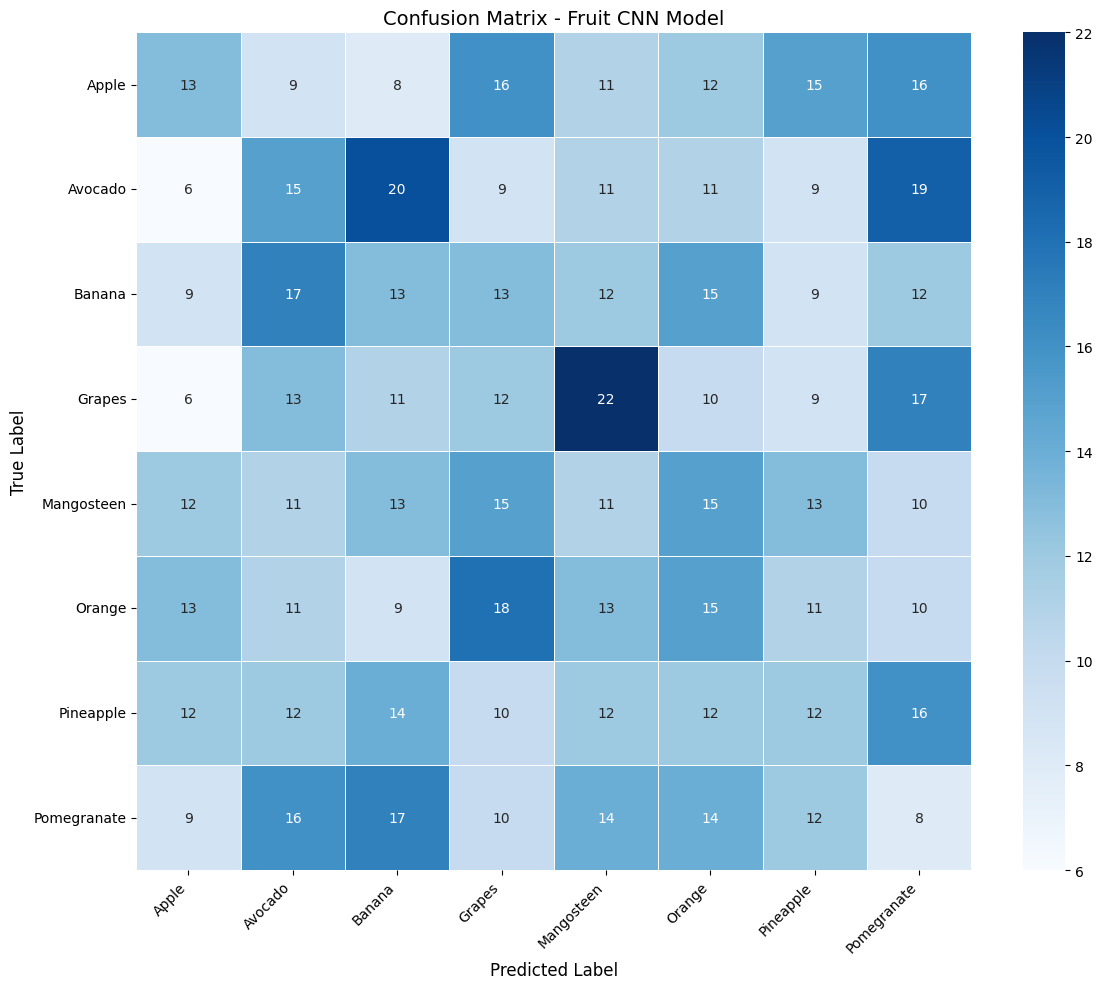

In [24]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Fruit CNN Model', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
print('\nMost Common Misclassifications (> 10 occurrences):')
print('-' * 60)

num_classes = len(class_names)

for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 10:   # threshold adjustable
            print(f'  {class_names[i]:<15} misclassified as '
                  f'{class_names[j]:<15} : {cm[i,j]} times')


Most Common Misclassifications (> 10 occurrences):
------------------------------------------------------------
  Apple           misclassified as Banana          : 15 times
  Apple           misclassified as Grapes          : 14 times
  Apple           misclassified as Mangosteen      : 14 times
  Apple           misclassified as Pineapple       : 15 times
  Apple           misclassified as Pomegranate     : 16 times
  Avocado         misclassified as Banana          : 14 times
  Avocado         misclassified as Grapes          : 11 times
  Avocado         misclassified as Mangosteen      : 17 times
  Avocado         misclassified as Pineapple       : 13 times
  Avocado         misclassified as Pomegranate     : 21 times
  Banana          misclassified as Apple           : 15 times
  Banana          misclassified as Avocado         : 12 times
  Banana          misclassified as Grapes          : 11 times
  Banana          misclassified as Orange          : 22 times
  Grapes          m

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess the image
img = image.load_img(r"image.jpg", target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

# Get predicted class index
class_index = np.argmax(prediction)

# Map to class labels
class_labels = list(train_data.class_indices.keys())
predicted_class = class_labels[class_index]

# Get confidence for the predicted class
confidence = prediction[0][class_index] * 100


plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()